In [2]:
%pip install itables

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from itables import show
import pandas as pd
import numpy as np

stud_perf = pd.read_csv("data\\student\\student-mat.csv",sep=";")

stud_perf.G3.describe()

show(stud_perf)

stud_perf[["Medu", "G2","G3"]].groupby("Medu").describe()

Loading ITables v2.6.2 from the internet... (need help?)


G2                                                       G3  \
      count       mean       std  min   25%   50%   75%   max  count   
Medu                                                                   
0       3.0  12.666667  4.041452  8.0  11.5  15.0  15.0  15.0    3.0   
1      59.0   9.169492  3.211792  0.0   7.5   9.0  11.0  16.0   59.0   
2     103.0  10.359223  3.342696  0.0   9.0  10.0  13.0  18.0  103.0   
3      99.0  10.444444  4.257580  0.0   8.0  11.0  13.0  18.0   99.0   
4     131.0  11.847328  3.602293  0.0   9.0  12.0  15.0  19.0  131.0   

                                                        
           mean       std  min   25%   50%   75%   max  
Medu                                                    
0     13.000000  3.464102  9.0  12.0  15.0  15.0  15.0  
1      8.677966  4.364594  0.0   7.5  10.0  11.0  16.0  
2      9.728155  4.636163  0.0   8.0  11.0  13.0  19.0  
3     10.303030  4.623486  0.0   8.0  10.0  13.0  19.0  
4     11.763359  4.267646  0.0   9.5  12.0  15.0  20.0

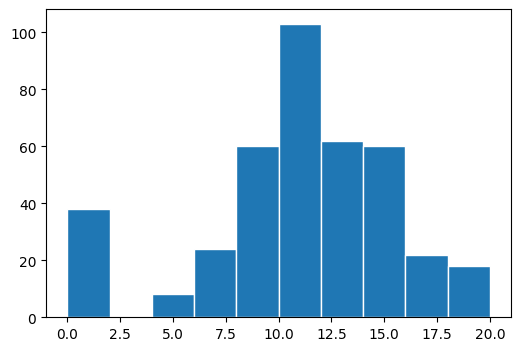

In [4]:
(stud_perf.guardian == "mother").mean()

stud_perf.groupby("Medu").apply(lambda x: (x.guardian == "mother").mean(), include_groups=False)

ax = stud_perf.G3.hist(grid=False, figsize=(6,4), bins=range(0,22,2), edgecolor="white")

array([[<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>,
        <Axes: title={'center': '2'}>],
       [<Axes: title={'center': '3'}>, <Axes: title={'center': '4'}>,
        <Axes: >]], dtype=object)

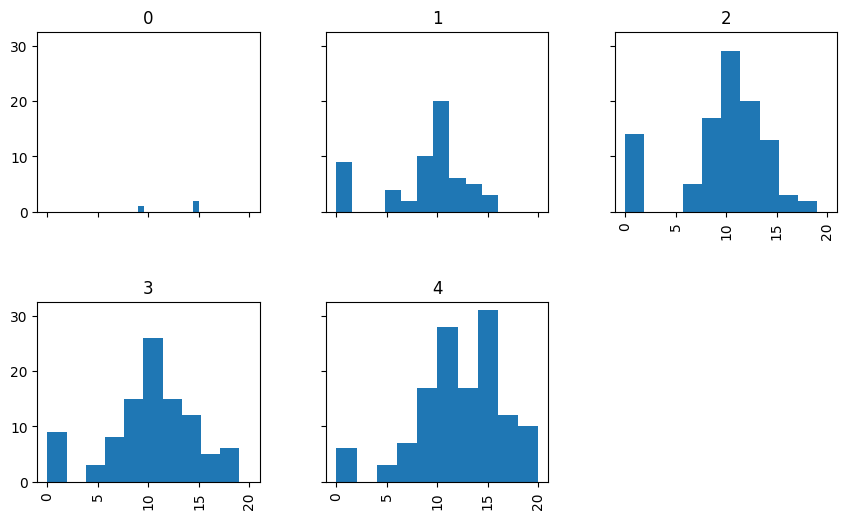

In [5]:
np.histogram(stud_perf.G3) # get height and bins

stud_perf.G3.hist(by=stud_perf.Medu, figsize = (10,6), layout=(2,3), sharex = True, sharey = True)


In [11]:
out2 = stud_perf.groupby("Medu")
for x in out2:
    print(f"{x[0]}: {x[1].shape}")

0: (3, 33)
1: (59, 33)
2: (103, 33)
3: (99, 33)
4: (131, 33)


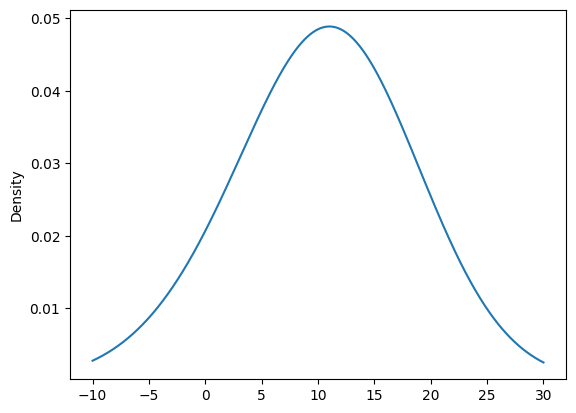

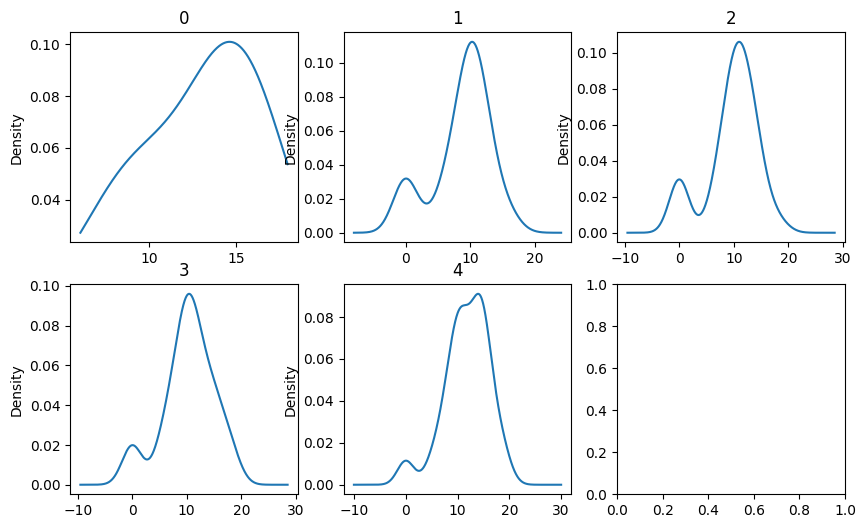

In [13]:
stud_perf.G3.plot(kind="kde", bw_method=1.5)

import matplotlib.pyplot as plt

f, axs = plt.subplots(2, 3, squeeze=False, figsize=(10,6))

for y, df0 in enumerate(out2):
    tmp = plt.subplot(2, 3, y+1)
    df0[1].G3.plot(kind="kde")
    tmp.set_title(df0[0])

G3    Axes(0.125,0.11;0.775x0.77)
dtype: object

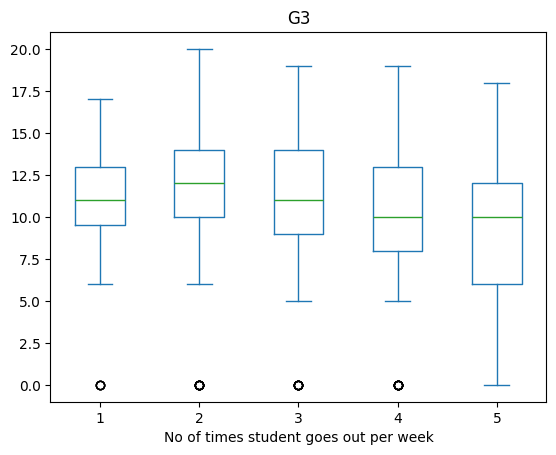

In [ ]:
stud_perf.plot.box(column="G3", by="goout", xlabel="No of times student goes out per week")


In [22]:
concrete = pd.read_csv(".\\data\\concrete+slump+test\\slump_test.data")
concrete.rename(columns= {
    "No": "id",
    "Compressive Strength (28-day)(Mpa)": "Comp_Strength",
    
}, inplace=True) #by default inplace is false

show(concrete)


Loading ITables v2.6.2 from the internet... (need help?)


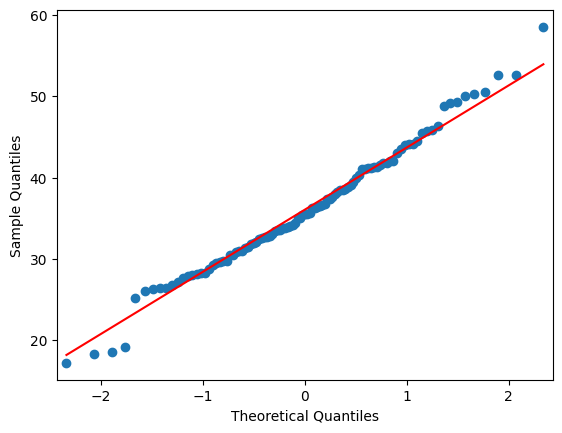

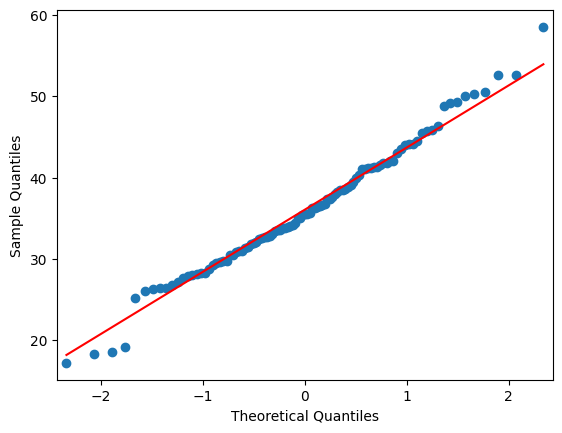

In [25]:
concrete_copy = concrete.copy() # create a separate copy

from scipy import stats
import statsmodels.api as sm

sm.qqplot(concrete.Comp_Strength, line="q")

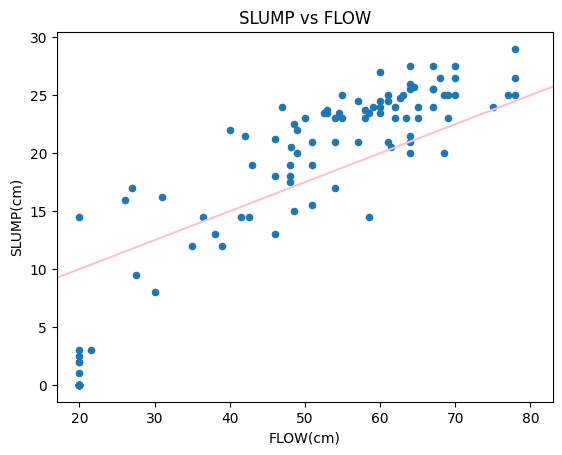

In [26]:
ax = concrete.plot(x="FLOW(cm)", y= "SLUMP(cm)", kind="scatter", title="SLUMP vs FLOW")
ax.axline((20,10), (80,25), color="pink")

In [30]:
corr = concrete[["Cement", "Slag", "Comp_Strength", "Water", "SLUMP(cm)","FLOW(cm)"]].corr()
corr

corr.style.background_gradient(cmap="coolwarm_r")

,Cement,Slag,Comp_Strength,Water,SLUMP(cm),FLOW(cm)
Cement,1.000000,-0.243553,0.445725,0.221091,0.145913,0.186461
Slag,-0.243553,1.000000,-0.331588,-0.026775,-0.284037,-0.327231
Comp_Strength,0.445725,-0.331588,1.000000,-0.254235,-0.223358,-0.124029
Water,0.221091,-0.026775,-0.254235,1.000000,0.466568,0.632026
SLUMP(cm),0.145913,-0.284037,-0.223358,0.466568,1.000000,0.906135
FLOW(cm),0.186461,-0.327231,-0.124029,0.632026,0.906135,1.000000
